## Explainability

In [11]:
import shap
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import os
import pandas as pd

In [12]:
sns.set_theme(style="darkgrid", context="paper", palette="bright")
plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 11
})

In [13]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [14]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
X_test_scaled = np.load(os.path.join(ARTIFACT_DIR,"X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR,"y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR,"encoder.pkl"))
feature_names = joblib.load(os.path.join(ARTIFACT_DIR,"feature_names.pkl"))
background = np.load(os.path.join(ARTIFACT_DIR,"shap_background.npy"))

### SHAP

In [15]:
sample_size = 1000
np.random.seed(42)
idx = np.random.choice(len(X_test_scaled), sample_size, replace = False)
X_sample = X_test_scaled[idx]
X_sample.shape

(1000, 45)

In [16]:
explainer = shap.Explainer(model, background)
shap_values = explainer(X_sample)

PermutationExplainer explainer: 1001it [01:43,  8.71it/s]                         


In [17]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

Model output shape: (None, 5)
Number of SHAP arrays: 1000
Number of labels: 5


/tmp/ipykernel_8854/2242344378.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


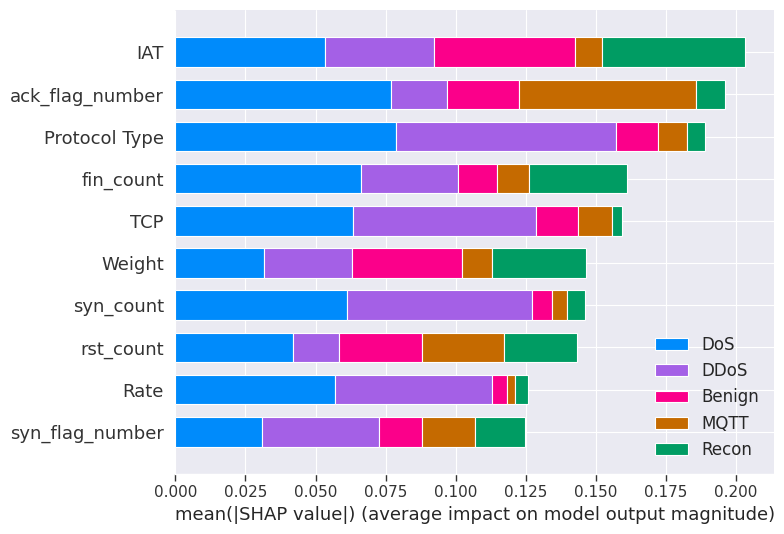

In [18]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names = feature_names,
    plot_type="bar",
    class_names = encoder.classes_,
    max_display=10,
    show = False
)
plt.savefig("GlobalSHAP.png", format="png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_8854/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


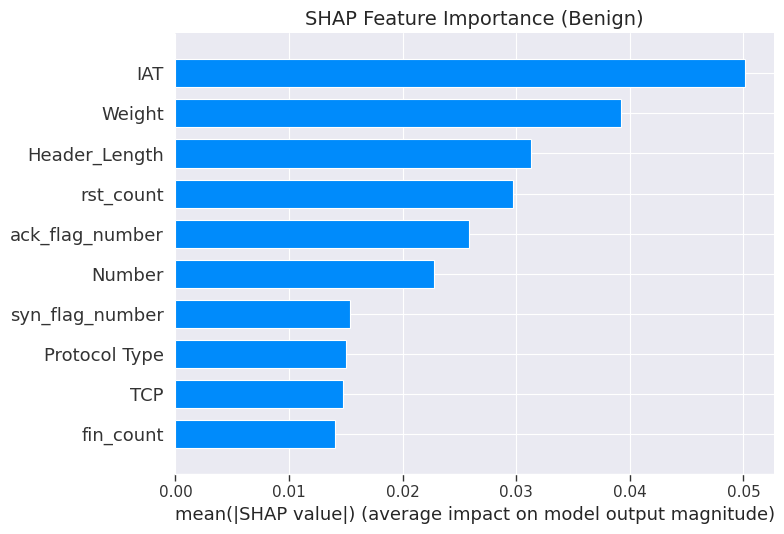

/tmp/ipykernel_8854/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


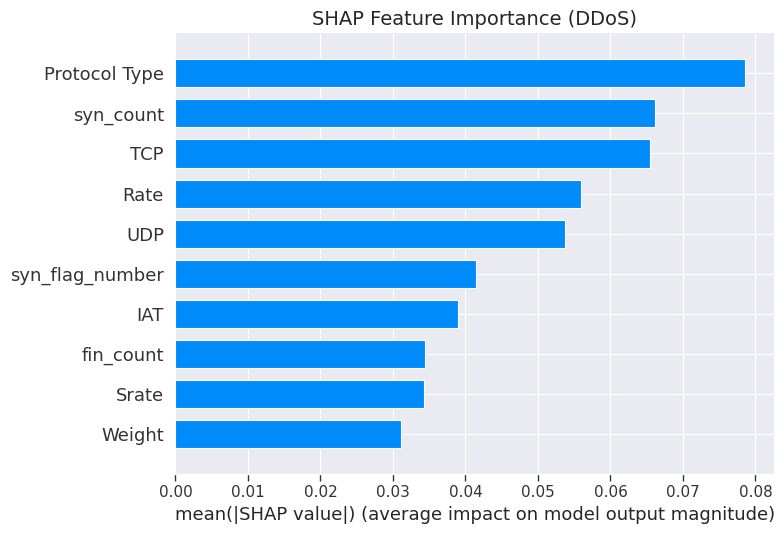

/tmp/ipykernel_8854/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


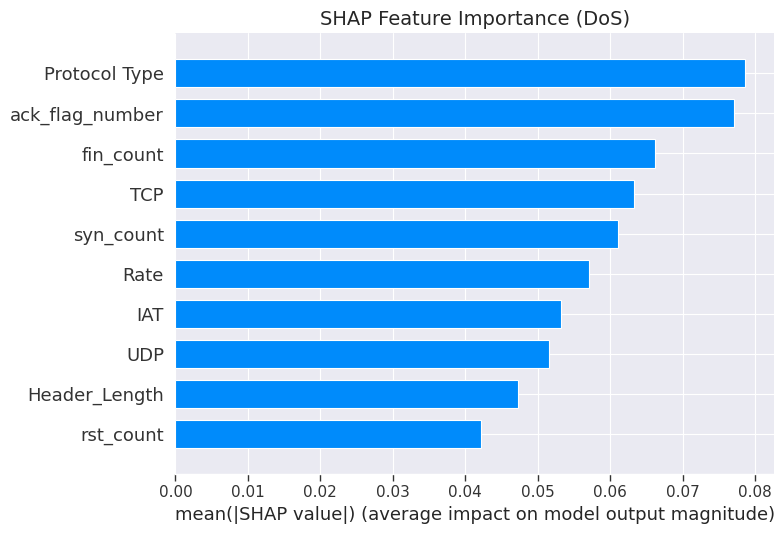

/tmp/ipykernel_8854/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


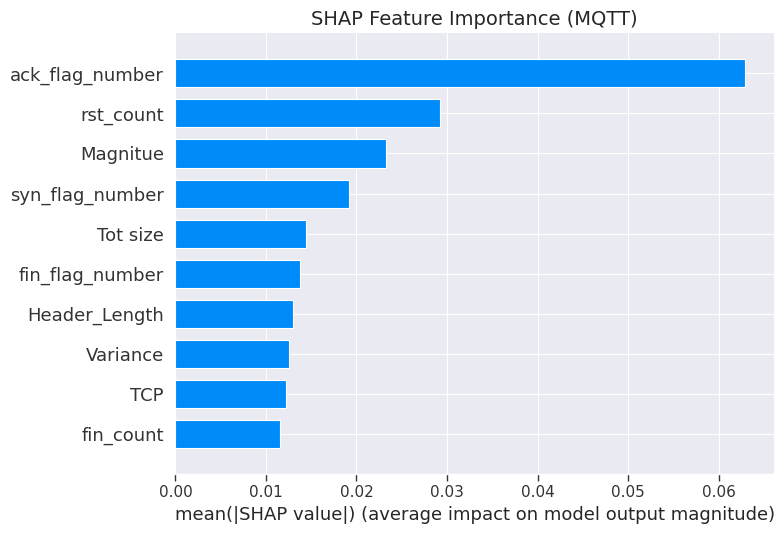

/tmp/ipykernel_8854/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


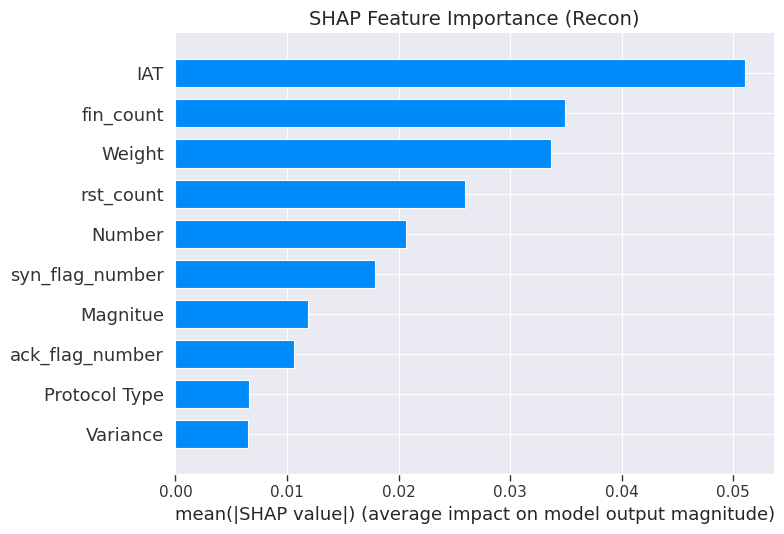

In [19]:
for i, class_label in enumerate(encoder.classes_):
    plt.title(f"SHAP Feature Importance ({class_label})")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names = feature_names,
        plot_type = "bar",
        show = True,
        max_display = 10
    )


/tmp/ipykernel_8854/689263845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


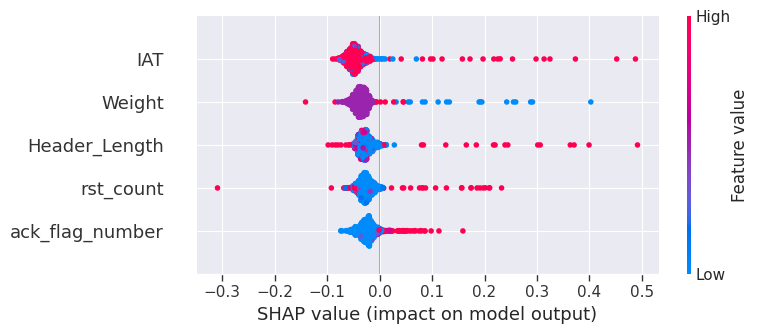

/tmp/ipykernel_8854/689263845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


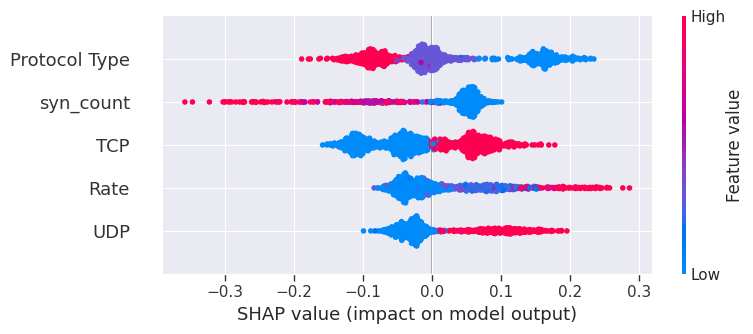

/tmp/ipykernel_8854/689263845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


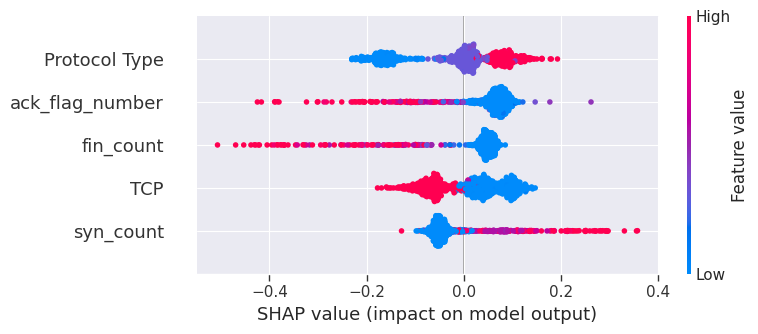

/tmp/ipykernel_8854/689263845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


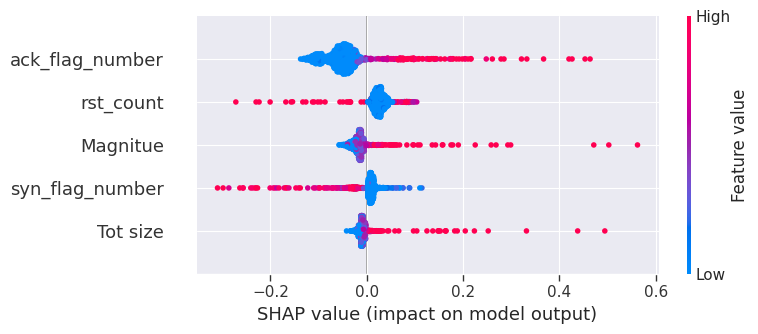

/tmp/ipykernel_8854/689263845.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


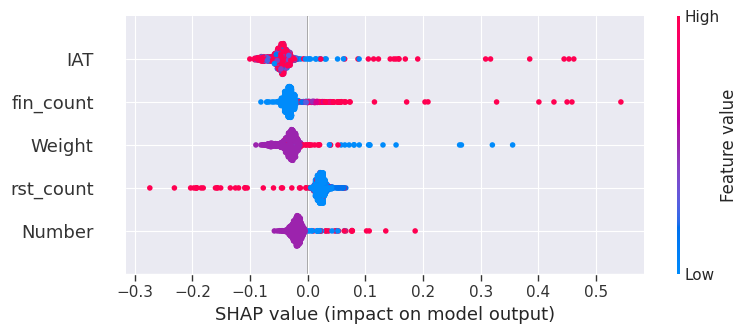

In [20]:
for i, class_label in enumerate(encoder.classes_):
    plt.figure(figsize=(14,12))
    # plt.title(f"Beeswarm Plot for Class: {class_label}")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names=feature_names,
        max_display = 5,
        show=False
    )
    filename = os.path.join(f"beeswarm_{class_label}.png")
    plt.savefig(filename, format="png", dpi=300, bbox_inches="tight")
    plt.show()